# 리텐션·코호트 분석 기준 설정을 위한 EDA


# 사용 데이터
전처리 코드를 통해 전처리한 데이터
- `01_user_profile_preprocessed.csv`
- `02_event_log_preprocessed.csv`


## 진행 흐름
1. 리텐션 분석 전처리
2. 리텐션 분석 전 기준 지정
3. 리텐션 분석 가능 범위

## 이번 EDA에서 정할 기준
1. Day 0 기준 설정
2. 활성 유저 판단 이벤트 설정
3. 알림 이벤트 제외 기준 확인
4. 로그 수집 장애 기간 플래그 확인
5. D0/D3/D7/D30 목표일 산정 가능 여부 확인
6. 월별 가입 코호트 기준 분석 가능 범위 확인


> 이번 단계에서는 실제 리텐션율을 계산하지 않습니다.  
> 먼저 **어떤 기준으로 리텐션을 계산할지**와 **어떤 구간을 주의해서 해석해야 하는지**를 정리합니다.

# 선 결론

## 이번 EDA에서 확정할 핵심 기준

| 구분 | 기준 |
|---|---|
| Day 0 | 가입일 |
| 활성 유저 | 해당 일자에 `앱실행` 이벤트가 존재하는 사용자 |
| 제외 이벤트 | `알림수신`, `알림오픈`은 앱 밖 OS 알림 이벤트이므로 활성 판단에서 제외 |
| 로그 수집 장애 기간 | 2025-03-10 ~ 2025-03-14 |
| 장애 기간 처리 | 삭제하지 않고 별도 플래그로 관리 |
| 코호트 기준 | 가입월(`signup_month`) |
| 리텐션 목표일 | D0, D3, D7, D30 |

## 추가 계산 기준

| 구분 | 기준 |
|---|---|
| 리텐션 판정 방식 | 정확히 N일째 되는 날짜에 `앱실행` 이벤트가 있는지 확인 |
| 사용자 중복 처리 | 목표일에 앱실행이 여러 번 있어도 사용자 1명은 1명으로 계산 |
| 관측 기간 밖 목표일 | 리텐션 산정 불가로 분리 |
| 장애 기간 목표일 | 삭제하지 않고 플래그로 관리 후 해석 시 주의 |

# 0. 라이브러리 호출 및 기본 설정

In [15]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# 한글 폰트 설정
import platform

if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 6)

# pandas 출력 옵션
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)

In [16]:
# 1. 프로젝트 경로 설정
# 프로젝트 최상위 폴더입니다.
# 본인 PC에서 GitHub 프로젝트가 있는 위치로 바꾸면 됩니다.
ROOT = Path(r"C:\Users\joon5\Documents\github\Anti-Churn-Committee")

# 원본 데이터가 들어있는 폴더
DATA_PROCESSED_DIR = ROOT / "data" / "processed"


# 원본 파일명입니다.
# data/raw 폴더 안에 이 이름으로 파일이 있어야 합니다.
USER_PROFILE_FILE = "01_user_profile_preprocessed.csv"
EVENT_LOG_FILE = "02_event_log_preprocessed.csv"

# 실제로 읽어올 파일 경로를 만듭니다.
USER_PROFILE_PATH = DATA_PROCESSED_DIR / USER_PROFILE_FILE
EVENT_LOG_PATH = DATA_PROCESSED_DIR / EVENT_LOG_FILE

print("USER_PROFILE_PATH:", USER_PROFILE_PATH)
print("EVENT_LOG_PATH   :", EVENT_LOG_PATH)
print("저장 폴더        :", DATA_PROCESSED_DIR)

user_profile = pd.read_csv(USER_PROFILE_PATH)
event_log = pd.read_csv(EVENT_LOG_PATH)

print("user_profile shape:", user_profile.shape)
print("event_log shape:", event_log.shape)

display(user_profile.head())
display(event_log.head())

USER_PROFILE_PATH: C:\Users\joon5\Documents\github\Anti-Churn-Committee\data\processed\01_user_profile_preprocessed.csv
EVENT_LOG_PATH   : C:\Users\joon5\Documents\github\Anti-Churn-Committee\data\processed\02_event_log_preprocessed.csv
저장 폴더        : C:\Users\joon5\Documents\github\Anti-Churn-Committee\data\processed
user_profile shape: (12500, 23)
event_log shape: (1757262, 11)


,user_id,signup_date,signup_channel,device,notification_agreed,notification_changed_date,signup_day,signup_month,signup_weekday,first_event_time,first_event_elapsed_hours,first_app_launch_time,app_launch_elapsed_hours,onboarding_completed_time,onboarding_elapsed_hours,app_launch_to_onboarding_hours,is_onboarding_completed,event_count_total,avg_events_per_session,is_signup_log_issue_period,is_no_event_user,is_notification_changed,is_first_event_before_signup
0,U0000001,2025-01-25,오가닉,iOS,True,NaN,2025-01-25,2025-01,토,2025-01-25 07:25:45,7.429167,2025-01-25 07:25:45,7.429167,2025-01-25 07:26:15,7.437500,0.008333,True,515,2.07,False,False,False,False
1,U0000002,2025-05-06,오가닉,iOS,False,2025-05-24,2025-05-06,2025-05,화,2025-05-06 16:23:12,16.386667,2025-05-06 16:23:12,16.386667,NaN,NaN,NaN,False,55,2.62,False,False,True,False
2,U0000003,2025-05-14,오가닉,iOS,False,NaN,2025-05-14,2025-05,수,2025-05-14 11:09:58,11.166111,2025-05-14 11:09:58,11.166111,NaN,NaN,NaN,False,3,1.50,False,False,False,False
3,U0000004,2025-02-23,퍼포먼스광고,Android,True,NaN,2025-02-23,2025-02,일,2025-02-23 07:15:35,7.259722,2025-02-23 07:15:35,7.259722,NaN,NaN,NaN,False,89,1.79,False,False,False,False
4,U0000005,2025-02-18,퍼포먼스광고,Android,True,NaN,2025-02-18,2025-02,화,2025-02-18 12:50:01,12.833611,2025-02-18 12:52:37,12.876944,2025-02-18 12:53:07,12.885278,0.008333,True,442,1.85,False,False,False,False


,user_id,event_time,event_type,session_id,notification_type,event_date,event_month,event_weekday,event_hour,is_log_issue_period,is_event_type_missing
0,U0000001,2025-01-25 07:25:45,앱실행,2858201769,NaN,2025-01-25,2025-01,토,7,False,False
1,U0000001,2025-01-25 07:26:15,온보딩_완료,2858201769,NaN,2025-01-25,2025-01,토,7,False,False
2,U0000001,2025-01-25 07:26:55,챌린지_탐색,2858201769,NaN,2025-01-25,2025-01,토,7,False,False
3,U0000001,2025-01-25 07:27:55,챌린지참여,2858201769,NaN,2025-01-25,2025-01,토,7,False,False
4,U0000001,2025-01-25 20:30:00,알림수신,NaN,광고성,2025-01-25,2025-01,토,20,False,False


# 날짜 컬럼 정리

In [17]:
# 사용자 프로필 날짜 컬럼 정리
user_profile["signup_date"] = pd.to_datetime(user_profile["signup_date"], errors="coerce")
user_profile["signup_day"] = pd.to_datetime(user_profile["signup_day"], errors="coerce").dt.normalize()
user_profile["signup_month"] = user_profile["signup_day"].dt.to_period("M").astype(str)

if "notification_changed_date" in user_profile.columns:
    user_profile["notification_changed_date"] = pd.to_datetime(
        user_profile["notification_changed_date"],
        errors="coerce"
    )

# 이벤트 로그 날짜 컬럼 정리
event_log["event_time"] = pd.to_datetime(event_log["event_time"], errors="coerce")
event_log["event_date"] = pd.to_datetime(event_log["event_date"], errors="coerce").dt.normalize()
event_log["event_month"] = event_log["event_date"].dt.to_period("M").astype(str)

# 분석 기준
issue_start = pd.Timestamp("2025-03-10")    # 로그 수집 장애 시작일
issue_end = pd.Timestamp("2025-03-14")      # 로그 수집 장애 종료일
retention_days_list = [0, 3, 7, 30]         # 리덴션 날짜

print("사용자 프로필 날짜 범위")
print("가입일 최소:", user_profile["signup_day"].min())
print("가입일 최대:", user_profile["signup_day"].max())

print("\n이벤트 로그 날짜 범위")
print("이벤트일 최소:", event_log["event_date"].min())
print("이벤트일 최대:", event_log["event_date"].max())

print("\n분석 기준")
print("로그 수집 장애 시작일:", issue_start)
print("로그 수집 장애 종료일:", issue_end)
print("리덴션 날짜:", retention_days_list)

사용자 프로필 날짜 범위
가입일 최소: 2025-01-01 00:00:00
가입일 최대: 2025-05-26 00:00:00

이벤트 로그 날짜 범위
이벤트일 최소: 2025-01-01 00:00:00
이벤트일 최대: 2025-06-30 00:00:00

분석 기준
로그 수집 장애 시작일: 2025-03-10 00:00:00
로그 수집 장애 종료일: 2025-03-14 00:00:00
리덴션 날짜: [0, 3, 7, 30]


# 기준 1: Day 0 기준 설정

리텐션 분석에서 Day 0은 사용자의 기준 시작일을 의미한다.  
Day 0을 어디로 설정하느냐에 따라 리텐션 분석의 해석 범위가 달라진다.

이번 분석에서는 아래 4가지 후보를 비교한다.

| Day 0 후보 | 의미 | 장점 | 주의점 |
|---|---|---|---|
| 가입일 | 사용자가 서비스에 가입한 날짜 | 전체 신규 가입자 기준으로 리텐션을 볼 수 있음 | 가입만 하고 앱을 실행하지 않은 사용자도 포함됨 |
| 첫 앱실행일 | 사용자가 처음 앱을 실행한 날짜 | 실제 앱 사용 시작 이후의 리텐션을 볼 수 있음 | 가입 후 앱을 실행하지 않은 사용자가 제외됨 |
| 온보딩 완료일 | 사용자가 온보딩을 완료한 날짜 | 온보딩 이후 유지율을 보기 좋음 | 온보딩을 완료하지 못한 사용자가 제외되어 리텐션이 높게 보일 수 있음 |
| 첫 핵심기능 사용일 | 기록/챌린지 등 핵심 기능을 처음 사용한 날짜 | 기능 경험 이후 잔존을 보기 좋음 | 적극적인 사용자만 남아 선택 편향이 커질 수 있음 |

따라서 각 후보별로 기준일을 만들 수 있는 사용자 수와 가입일 이후 기준일까지 걸린 시간을 비교한 뒤,  
이번 과제의 목적에 가장 적합한 Day 0 기준을 선택한다.

## 1-1. 가입월별 사용자 수 확인
가입월별 사용자 수를 먼저 확인      
월별 가입 코호트 분석의 기준 모집단을 확인하는 용도

In [ ]:
evn_start = event_log["event_date"].min()
evn_end = event_log["event_date"].max()

issue_start = pd.Timestamp("2025-03-10")
issue_end = pd.Timestamp("2025-03-14")

period_summary = pd.DataFrame({
    "항목": [
        "가입 시작일",
        "가입 종료일",
        "이벤트 관측 시작일",
        "이벤트 관측 종료일",
        "로그 수집 장애 시작일",
        "로그 수집 장애 종료일",
        "전체 가입자 수",
        "이벤트 로그 사용자 수",
        "프로필에는 있으나 이벤트 로그에는 없는 사용자 수"
    ],
    "값": [
        user_profile["signup_day"].min(),
        user_profile["signup_day"].max(),
        evn_start,
        evn_end,
        issue_start,
        issue_end,
        user_profile["user_id"].nunique(),
        event_log["user_id"].nunique(),
        int(user_profile.get("is_no_event_user", pd.Series(False, index=user_profile.index)).sum())
    ]
})

display(period_summary)

,항목,값
0,가입 시작일,2025-01-01 00:00:00
1,가입 종료일,2025-05-26 00:00:00
2,이벤트 관측 시작일,2025-01-01 00:00:00
3,이벤트 관측 종료일,2025-06-30 00:00:00
4,로그 수집 장애 시작일,2025-03-10 00:00:00
5,로그 수집 장애 종료일,2025-03-14 00:00:00
6,전체 가입자 수,12500
7,이벤트 로그 사용자 수,12453
8,프로필에는 있으나 이벤트 로그에는 없는 사용자 수,47


,signup_month,user_count
0,2025-01,2124
1,2025-02,4384
2,2025-03,2122
3,2025-04,2082
4,2025-05,1788


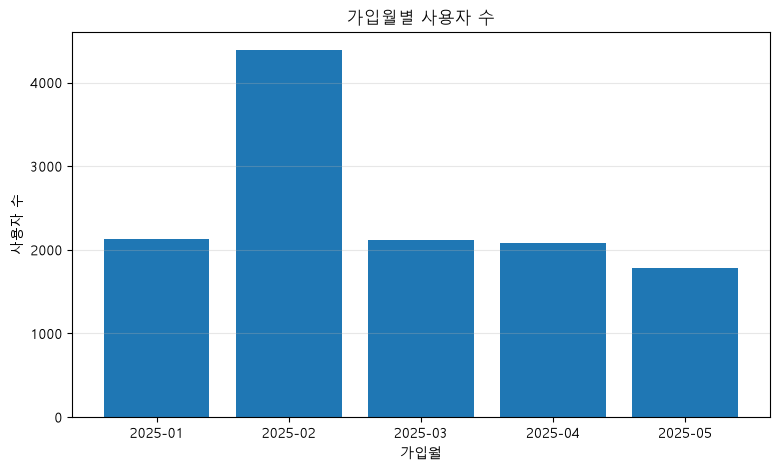

In [ ]:
signup_month_summary = (
    user_profile
    .groupby("signup_month", as_index=False)
    .agg(user_count=("user_id", "nunique"))
    .sort_values("signup_month")
)

display(signup_month_summary)

plt.figure(figsize=(9, 5))
plt.bar(signup_month_summary["signup_month"], signup_month_summary["user_count"])
plt.title("가입월별 사용자 수")
plt.xlabel("가입월")
plt.ylabel("사용자 수")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

### 확인 포인트
- 가입자는 2025년 1월~5월에 존재
    - 가장 가입자가 많은 월은 **2025-02월(4,384명)**
    - 가장 가입자가 적은 월은 **2025-05월(1,788명)**
- 이벤트 로그는 2025년 1월~6월까지 관측됨
- 때문에 **가입월별 D30 목표일이 모두 관측 기간 안에 들어오는지 확인 해야함**

### 확인 포인트
- 가입자는 2025년 1월~5월에 존재
    - 가장 가입자가 많은 월은 **2025-02월(4,384명)**
    - 가장 가입자가 적은 월은 **2025-05월(1,788명)**
- 이벤트 로그는 2025년 1월~6월까지 관측됨
- 때문에 **가입월별 D30 목표일이 모두 관측 기간 안에 들어오는지 확인 해야함**

# 기준 2: 활성 유저 판단 이벤트 설정
리텐션에서 활성 유저는 **해당 일자에 `앱실행` 이벤트가 존재하는 사용자**로 판단


리텐션은 사용자가 앱에 다시 돌아왔는지를 보는 지표로써      
 기록, 챌린지, 알림 이벤트 보단, 실제 앱 진입을 의미하는 `앱실행`을 활성 판단 기준으로 두는것이 적절


## 2-1. Event Type별 이벤트 수 확인
어떤 이벤트가 얼마나 발생했는지 확인한 뒤, 리텐션 활성 판단에 사용할 이벤트와 제외할 이벤트를 구분

,event_type_display,event_count,user_count,retention_active_judgement,exclude_reason
6,앱실행,728657,12447,활성 인정,앱을 실제로 실행한 이벤트
2,수면기록,242978,11473,활성 제외,기능 사용 이벤트이지만 활성 판단 기준에서는 제외
4,알림수신,194324,8139,활성 제외,앱 밖 OS 알림 이벤트
8,운동기록,131269,10418,활성 제외,기능 사용 이벤트이지만 활성 판단 기준에서는 제외
1,마음챙김,130344,10837,활성 제외,기능 사용 이벤트이지만 활성 판단 기준에서는 제외
3,식단기록,101366,10264,활성 제외,기능 사용 이벤트이지만 활성 판단 기준에서는 제외
10,챌린지참여,96829,9372,활성 제외,기능 사용 이벤트이지만 활성 판단 기준에서는 제외
9,챌린지_탐색,78101,9104,활성 제외,기능 사용 이벤트이지만 활성 판단 기준에서는 제외
0,Event_Type 결측,26456,7206,활성 제외,식별 불가능한 이벤트
5,알림오픈,21219,5127,활성 제외,앱 밖 OS 알림 이벤트


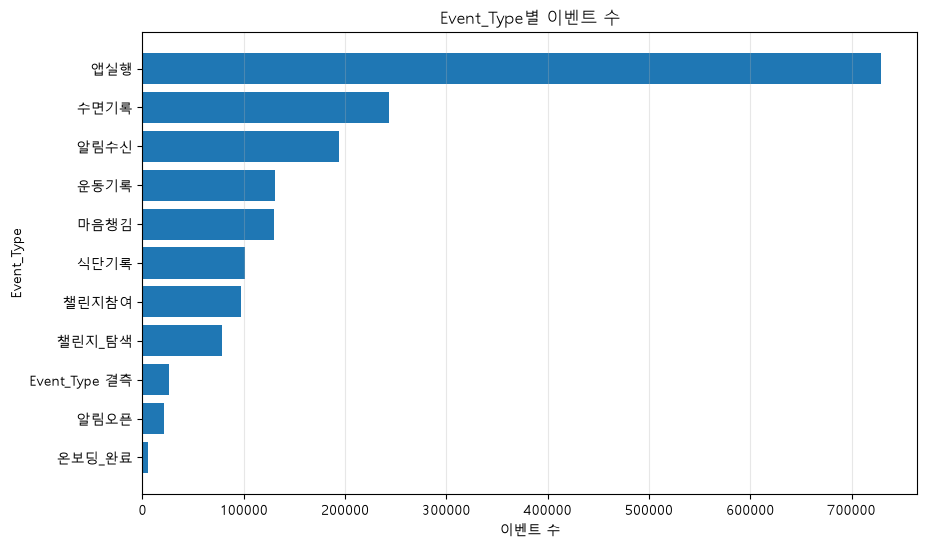

In [22]:
event_type_summary = (
    event_log
    .assign(event_type_display=event_log["event_type"].fillna("Event_Type 결측"))
    .groupby("event_type_display", as_index=False)
    .agg(
        event_count=("user_id", "size"),
        user_count=("user_id", "nunique")
    )
    .sort_values("event_count", ascending=False)
)

event_type_summary["retention_active_judgement"] = np.where(
    event_type_summary["event_type_display"].eq("앱실행"),
    "활성 인정",
    "활성 제외"
)

event_type_summary["exclude_reason"] = np.select(
    [
        event_type_summary["event_type_display"].eq("앱실행"),
        event_type_summary["event_type_display"].isin(["알림수신", "알림오픈"]),
        event_type_summary["event_type_display"].eq("Event_Type 결측")
    ],
    [
        "앱을 실제로 실행한 이벤트",
        "앱 밖 OS 알림 이벤트",
        "식별 불가능한 이벤트"
    ],
    default="기능 사용 이벤트이지만 활성 판단 기준에서는 제외"
)

display(event_type_summary)

# 그래프
plot_event_type = event_type_summary.sort_values("event_count")

plt.figure(figsize=(10, 6))
plt.barh(plot_event_type["event_type_display"], plot_event_type["event_count"])
plt.title("Event_Type별 이벤트 수")
plt.xlabel("이벤트 수")
plt.ylabel("Event_Type")
plt.grid(axis="x", alpha=0.3)
plt.show()

## 2-2. 활성 판단 사용/제외 이벤트 규모 확인

`앱실행`만 활성 판단에 사용고, 나머지 이벤트는 모두 활성 판단에서 제외        
아래 표와 그래프는 이 기준이 데이터에서 어느 정도 규모를 갖는지 확인

,retention_active_judgement,event_count,event_ratio
0,활성 인정,728657,41.47
1,활성 제외,1028605,58.53


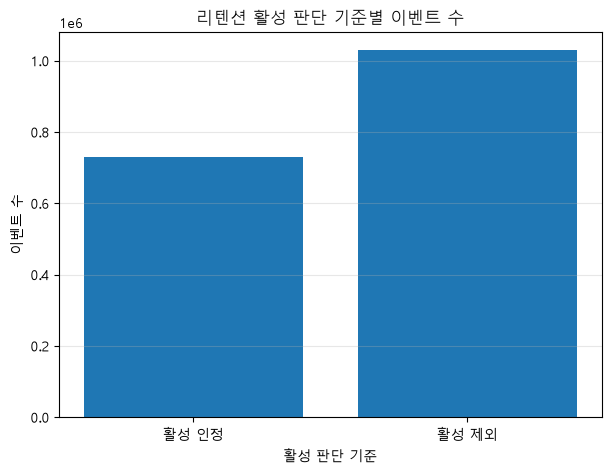

In [23]:
# 리텐션 활성 판단 기준: 이밴트 수
active_judgement_summary = (
    event_type_summary
    .groupby("retention_active_judgement", as_index=False)
    .agg(event_count=("event_count", "sum"))
)

active_judgement_summary["event_ratio"] = (
    active_judgement_summary["event_count"]
    / active_judgement_summary["event_count"].sum()
    * 100
).round(2)

display(active_judgement_summary)

plt.figure(figsize=(7, 5))
plt.bar(active_judgement_summary["retention_active_judgement"], active_judgement_summary["event_count"])
plt.title("리텐션 활성 판단 기준별 이벤트 수")
plt.xlabel("활성 판단 기준")
plt.ylabel("이벤트 수")
plt.grid(axis="y", alpha=0.3)
plt.show()

# 기준 3: 알림 이벤트 제외 기준 확인
- `알림수신`, `알림오픈`은 리텐션 활성 판단에서 제외


알림 이벤트는 앱 내부 행동이라기보다 앱 밖의 OS 알림 환경에서 발생할 수 있다.     
따라서 알림은 활성 유저 판정에는 사용하지 않는다.       
(리텐션의 원인 분석용 보조 지표로는 활용 가능할것으로 판단)

,event_type_display,event_count,user_count,retention_active_judgement,exclude_reason
4,알림수신,194324,8139,활성 제외,앱 밖 OS 알림 이벤트
5,알림오픈,21219,5127,활성 제외,앱 밖 OS 알림 이벤트


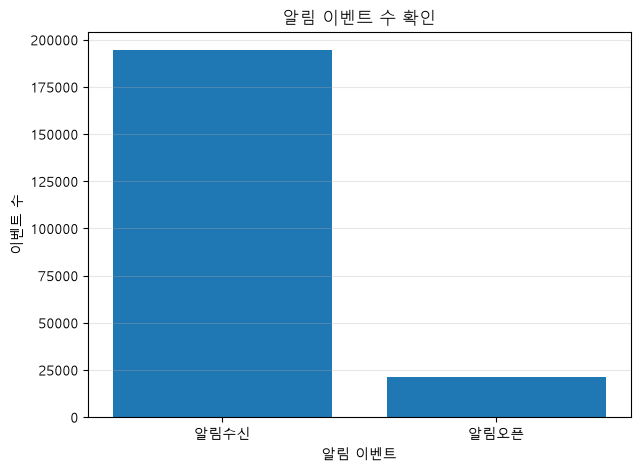

In [24]:
notification_event_check = (
    event_type_summary
    .query("event_type_display in ['알림수신', '알림오픈']")
    .loc[:, [
        "event_type_display",
        "event_count",
        "user_count",
        "retention_active_judgement",
        "exclude_reason"
    ]]
    .sort_values("event_type_display")
)

display(notification_event_check)

plt.figure(figsize=(7, 5))
plt.bar(notification_event_check["event_type_display"], notification_event_check["event_count"])
plt.title("알림 이벤트 수 확인")
plt.xlabel("알림 이벤트")
plt.ylabel("이벤트 수")
plt.grid(axis="y", alpha=0.3)
plt.show()

# 기준 4: 로그 수집 장애 기간 플래그 확인

- 로그 수집 장애 기간: **2025-03-10 ~ 2025-03-14**
- `final_preprocessed_v1.ipynb`에서 이미 생성된 `is_log_issue_period` 컬럼을 사용
- `is_log_issue_period` 사용

이 기간의 데이터는 불완전하기 때문에, 단순히 무활동으로 해석하면 위험하다 판단됨        
따라서 전처리된 장애 기간 플래그를 기준으로 이후 리텐션 분석에서 해석 한계로 함께 확인

## 4-1. 리텐션 분석용 이벤트 기준 테이블 생성
프로필 정보와 이벤트 로그를 결합하고, 리텐션 기준 확인에 필요한 최소 파생 컬럼만 추가

- `is_log_issue_period`는 이미 전처리 완료 데이터에 있는 컬럼을 그대로 사용
- `event_day_from_signup`, `is_retention_active_event`, `is_notification_event`은 리텐션 기준 확인용

In [25]:
required_profile_cols = [
    "user_id",
    "signup_day",
    "signup_month",
    "is_no_event_user",
    "is_signup_log_issue_period"
]

required_event_cols = [
    "user_id",
    "event_date",
    "event_type",
    "is_log_issue_period"
]

missing_profile_cols = [col for col in required_profile_cols if col not in user_profile.columns]
missing_event_cols = [col for col in required_event_cols if col not in event_log.columns]

profile_for_merge = user_profile[required_profile_cols].copy()

event_log_retention_base = event_log.merge(
    profile_for_merge,
    on="user_id",
    how="left"
)

# 가입일 기준으로 이벤트가 가입 후 며칠째 발생했는지 계산합니다.
event_log_retention_base["event_day_from_signup"] = (
    event_log_retention_base["event_date"] - event_log_retention_base["signup_day"]
).dt.days

# 리텐션 분석 기준 컬럼입니다.
# is_log_issue_period는 전처리 완료 데이터의 기존 컬럼을 그대로 사용합니다.
event_log_retention_base["is_retention_active_event"] = event_log_retention_base["event_type"].eq("앱실행")
event_log_retention_base["is_notification_event"] = event_log_retention_base["event_type"].isin(["알림수신", "알림오픈"])
event_log_retention_base["is_event_before_signup"] = event_log_retention_base["event_day_from_signup"].lt(0)

retention_base_check = pd.DataFrame({
    "항목": [
        "이벤트 로그 행 수",
        "프로필과 매칭되지 않은 이벤트 수",
        "가입일 이전 이벤트 수",
        "리텐션 활성 이벤트 수",
        "알림 이벤트 수",
        "로그 장애 기간 이벤트 수"
    ],
    "값": [
        len(event_log_retention_base),
        int(event_log_retention_base["signup_day"].isna().sum()),
        int(event_log_retention_base["is_event_before_signup"].sum()),
        int(event_log_retention_base["is_retention_active_event"].sum()),
        int(event_log_retention_base["is_notification_event"].sum()),
        int(event_log_retention_base["is_log_issue_period"].sum())
    ]
})

display(retention_base_check)
display(event_log_retention_base.head())

,항목,값
0,이벤트 로그 행 수,1757262
1,프로필과 매칭되지 않은 이벤트 수,0
2,가입일 이전 이벤트 수,0
3,리텐션 활성 이벤트 수,728657
4,알림 이벤트 수,215543
5,로그 장애 기간 이벤트 수,20862


,user_id,event_time,event_type,session_id,notification_type,event_date,event_month,event_weekday,event_hour,is_log_issue_period,is_event_type_missing,signup_day,signup_month,is_no_event_user,is_signup_log_issue_period,event_day_from_signup,is_retention_active_event,is_notification_event,is_event_before_signup
0,U0000001,2025-01-25 07:25:45,앱실행,2858201769,NaN,2025-01-25,2025-01,토,7,False,False,2025-01-25,2025-01,False,False,0,True,False,False
1,U0000001,2025-01-25 07:26:15,온보딩_완료,2858201769,NaN,2025-01-25,2025-01,토,7,False,False,2025-01-25,2025-01,False,False,0,False,False,False
2,U0000001,2025-01-25 07:26:55,챌린지_탐색,2858201769,NaN,2025-01-25,2025-01,토,7,False,False,2025-01-25,2025-01,False,False,0,False,False,False
3,U0000001,2025-01-25 07:27:55,챌린지참여,2858201769,NaN,2025-01-25,2025-01,토,7,False,False,2025-01-25,2025-01,False,False,0,False,False,False
4,U0000001,2025-01-25 20:30:00,알림수신,NaN,광고성,2025-01-25,2025-01,토,20,False,False,2025-01-25,2025-01,False,False,0,False,True,False


## 4-2. 로그 장애 기간 이벤트 분포 확인
`is_log_issue_period` 장애 기간 플래그가 실제 데이터에서 어느 정도 규모인지 확인

,period_type,event_count,user_count
0,정상 관측 기간,1736400,12398
1,로그 장애 기간,20862,2367


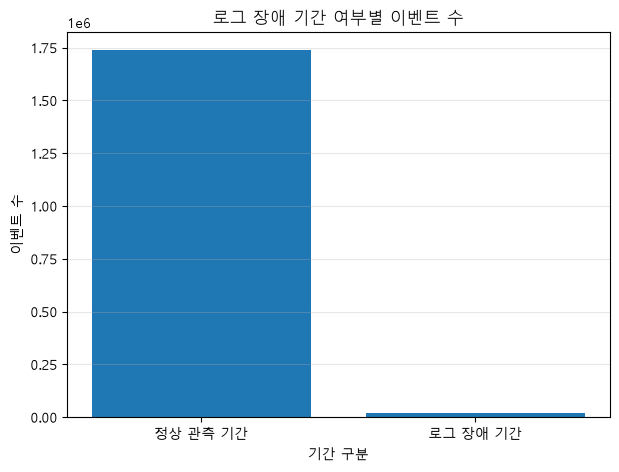

In [26]:
log_issue_event_summary = (
    event_log_retention_base
    .groupby("is_log_issue_period", as_index=False)
    .agg(
        event_count=("user_id", "size"),
        user_count=("user_id", "nunique")
    )
)

log_issue_event_summary["period_type"] = np.where(
    log_issue_event_summary["is_log_issue_period"],
    "로그 장애 기간",
    "정상 관측 기간"
)

log_issue_event_summary = log_issue_event_summary[[
    "period_type",
    "event_count",
    "user_count"
]]

display(log_issue_event_summary)

plt.figure(figsize=(7, 5))
plt.bar(log_issue_event_summary["period_type"], log_issue_event_summary["event_count"])
plt.title("로그 장애 기간 여부별 이벤트 수")
plt.xlabel("기간 구분")
plt.ylabel("이벤트 수")
plt.grid(axis="y", alpha=0.3)
plt.show()

로그 장애 기간에도 이벤트가 일부 존재하므로, 해당 기간을 단순히 통째로 삭제보단 불완전 관측 구간로 판단     
장애 기간에 기록된 이벤트는 20,862건, 관련 사용자는 2,367명     
이후 리텐션 목표일이 이 기간에 걸리는 사용자는 무활동으로 단정하지 않고, 별도 플래그로 확인

# 리텐션 분석용 활성 일자 테이블 생성
- 한 사용자가 같은 날 앱실행을 여러 번 해도, 리텐션 판정에서는 1명으로 판정
- 따라서 `user_id` + `event_date` 기준으로 중복 제거합니다.

In [27]:
user_active_days_for_retention = (
    event_log_retention_base
    .query("is_retention_active_event == True")
    .query("event_day_from_signup >= 0")
    .loc[:, [
        "user_id",
        "signup_day",
        "signup_month",
        "event_date",
        "event_day_from_signup",
        "is_log_issue_period"
    ]]
    .drop_duplicates()
    .sort_values(["user_id", "event_date"])
)

display(user_active_days_for_retention.head())
print("리텐션 활성 일자 테이블 shape:", user_active_days_for_retention.shape)
print("활성 사용자 수:", user_active_days_for_retention["user_id"].nunique())

,user_id,signup_day,signup_month,event_date,event_day_from_signup,is_log_issue_period
0,U0000001,2025-01-25,2025-01,2025-01-25,0,False
5,U0000001,2025-01-25,2025-01,2025-01-26,1,False
18,U0000001,2025-01-25,2025-01,2025-01-27,2,False
33,U0000001,2025-01-25,2025-01,2025-01-28,3,False
39,U0000001,2025-01-25,2025-01,2025-01-29,4,False


리텐션 활성 일자 테이블 shape: (307753, 6)
활성 사용자 수: 12447


## 가입 후 경과일별 앱실행 분포 확인
리텐션율 계산이 아닌, 가입 후 며칠째 앱실행 이벤트가 주로 발생하는지 확인

,event_day_from_signup,total_event_count,active_event_count,notification_event_count
0,0,121777,44883,8882
1,1,74155,29161,7517
2,2,69300,27050,7019
3,3,64121,25064,6522
4,4,61067,23804,5963
5,5,57198,22312,5638
6,6,53657,20936,5259
7,7,30355,12321,3715
8,8,29388,11995,3590
9,9,28076,11357,3435


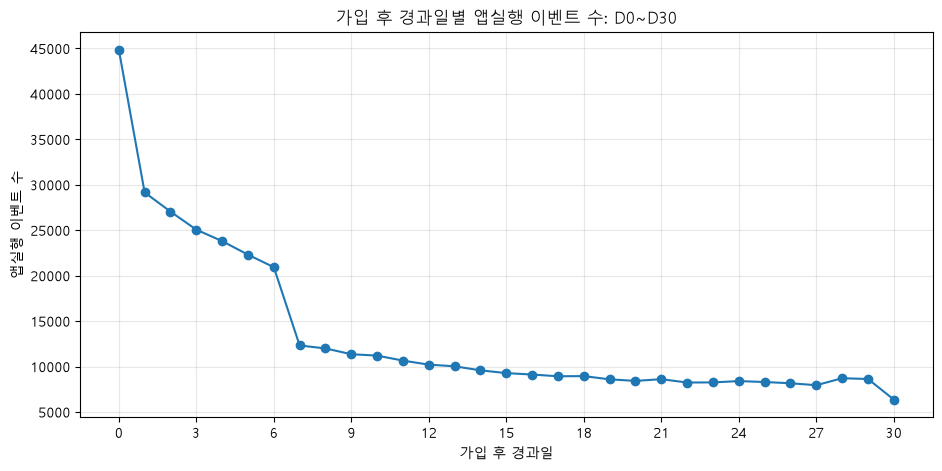

In [28]:
event_day_summary = (
    event_log_retention_base
    .query("0 <= event_day_from_signup <= 30")
    .groupby("event_day_from_signup", as_index=False)
    .agg(
        total_event_count=("user_id", "size"),
        active_event_count=("is_retention_active_event", "sum"),
        notification_event_count=("is_notification_event", "sum")
    )
)

display(event_day_summary.head(31))

plt.figure(figsize=(11, 5))
plt.plot(event_day_summary["event_day_from_signup"], event_day_summary["active_event_count"], marker="o")
plt.title("가입 후 경과일별 앱실행 이벤트 수: D0~D30")
plt.xlabel("가입 후 경과일")
plt.ylabel("앱실행 이벤트 수")
plt.xticks(range(0, 31, 3))
plt.grid(alpha=0.3)
plt.show()

- D0 앱실행 활성 사용자는 12,247명
- D30 앱실행 활성 사용자는 3,037명

## 기준 5: D0/D3/D7/D30 목표일 산정 가능 여부 확인

## 기준
- 리텐션 목표일: **D0, D3, D7, D30**
- 각 사용자의 `signup_day + N일`을 목표일로 계산
- 목표일이 관측 기간 안에 있는지, 로그 장애 기간에 걸리는지 확인
- 목표일이 로그 장애 기간에 걸리는지도 따로 플래그 처리


리텐션 목표일별로 전체 사용자 중 몇 명이 관측 기간 안에 들어오는지, 그리고 몇 명이 로그 수집 장애 기간에 걸리는지 확인


> 여기서 새로 만드는 `is_target_log_issue_period`는 **이벤트 발생일 기준 플래그가 아닌, 리텐션 목표일이 장애 기간에 걸리는지 확인하는 별도 플래그**
- 이건 제가 햇갈려서 넣은 설명

In [29]:
retention_days = pd.DataFrame({
    "retention_day": retention_days_list
})

user_targets = (
    user_profile[[
        "user_id",
        "signup_day",
        "signup_month",
        "is_no_event_user",
        "is_signup_log_issue_period"
    ]]
    .merge(retention_days, how="cross")
)

user_targets["target_date"] = user_targets["signup_day"] + pd.to_timedelta(user_targets["retention_day"], unit="D")
user_targets["retention_day_label"] = "D" + user_targets["retention_day"].astype(str)

user_targets["is_target_observable"] = user_targets["target_date"].between(obs_start, obs_end)
user_targets["is_target_log_issue_period"] = user_targets["target_date"].between(issue_start, issue_end)
user_targets["is_normal_retention_target"] = (
    user_targets["is_target_observable"]
    & ~user_targets["is_target_log_issue_period"]
)

user_targets["retention_target_status"] = np.select(
    [
        ~user_targets["is_target_observable"],
        user_targets["is_target_log_issue_period"]
    ],
    [
        "관측기간 밖",
        "목표일 장애기간"
    ],
    default="정상 산정 가능"
)

display(user_targets.head(12))

NameError: name 'obs_start' is not defined

## 5-1. 리텐션 목표일별 산정 가능 상태 확인
아래 표는 D0/D3/D7/D30별로 전체 사용자 중 몇 명이 정상적으로 산정 가능한지, 그리고 몇 명이 장애 기간에 걸리는지 확인
- `observable_user_count`: 목표일이 이벤트 관측 기간 안에 있는 사용자 수
- `issue_target_user_count`: 목표일이 로그 수집 장애 기간에 걸리는 사용자 수
- `normal_target_user_count`: 관측 가능하고 장애 기간에도 걸리지 않는 사용자 수

retention_target_status,장애기간 주의,정상 산정 가능
retention_day,,
0,341,12159
3,341,12159
7,368,12132
30,771,11729


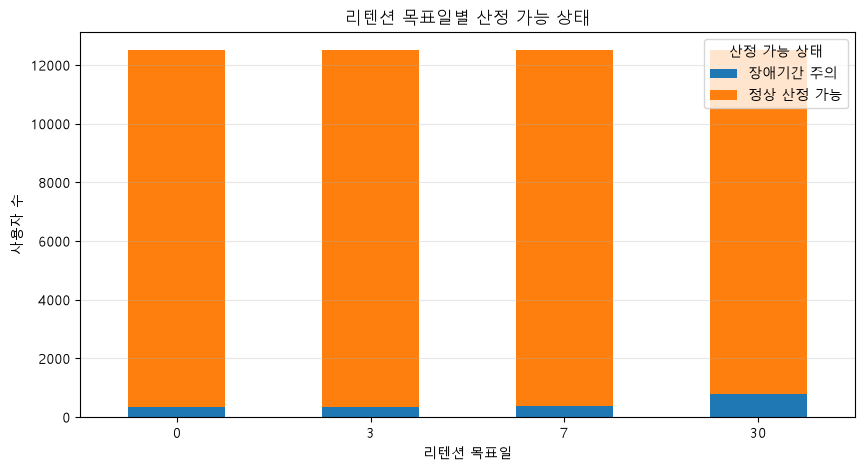

In [ ]:
coverage_summary = (
    user_targets
    .groupby("retention_day", as_index=False)
    .agg(
        total_user_count=("user_id", "nunique"),
        observable_user_count=("is_target_observable", "sum"),
        issue_target_user_count=("is_target_log_issue_period", "sum")
    )
)

coverage_summary["normal_target_user_count"] = (
    coverage_summary["observable_user_count"] - coverage_summary["issue_target_user_count"]
)

coverage_summary["observable_rate"] = (
    coverage_summary["observable_user_count"] / coverage_summary["total_user_count"] * 100
).round(2)
coverage_summary["issue_target_rate"] = (
    coverage_summary["issue_target_user_count"] / coverage_summary["total_user_count"] * 100
).round(2)
coverage_summary["normal_target_rate"] = (
    coverage_summary["normal_target_user_count"] / coverage_summary["total_user_count"] * 100
).round(2)

display(coverage_summary)

In [ ]:
status_by_day = pd.crosstab(
    user_targets["retention_day"],
    user_targets["retention_target_status"]
)

status_by_day = status_by_day.reindex(index=[0, 1, 3, 7, 14, 30])
display(status_by_day)

status_by_day.plot(kind="bar", stacked=True, figsize=(10, 5))
plt.title("리텐션 목표일별 산정 가능 상태")
plt.xlabel("리텐션 목표일")
plt.ylabel("사용자 수")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="산정 가능 상태")
plt.show()

# 기준 6: 월별 가입 코호트 기준 분석 가능 범위 확인

- 코호트 기준은 **가입월(`signup_month`)**
- 월별 전체 이벤트 수가 아니라, 가입월별 사용자 집단의 D0/D3/D7/D30 목표일 산정 가능 범위를 확인

6월은 신규 가입이 없거나 적어 월별 전체 이벤트 수만으로는 사용량 감소와 리텐션 하락을 구분하기 어렵다.      
따라서 가입월별 코호트 기준으로 사용자가 어느 시점에서 이탈하는지 확인하는 방식이 더 적합

In [ ]:
cohort_target_summary = (
    user_targets
    .groupby(["signup_month", "retention_day"], as_index=False)
    .agg(
        cohort_user_count=("user_id", "nunique"),
        observable_user_count=("is_target_observable", "sum"),
        issue_target_user_count=("is_target_log_issue_period", "sum")
    )
)

cohort_target_summary["normal_target_user_count"] = (
    cohort_target_summary["observable_user_count"] - cohort_target_summary["issue_target_user_count"]
)

cohort_target_summary["normal_target_rate"] = (
    cohort_target_summary["normal_target_user_count"] / cohort_target_summary["cohort_user_count"] * 100
).round(2)

cohort_target_summary["issue_target_rate"] = (
    cohort_target_summary["issue_target_user_count"] / cohort_target_summary["cohort_user_count"] * 100
).round(2)

display(cohort_target_summary)

In [ ]:
normal_rate_matrix = cohort_target_summary.pivot(
    index="signup_month",
    columns="retention_day",
    values="normal_target_rate"
)

issue_count_matrix = cohort_target_summary.pivot(
    index="signup_month",
    columns="retention_day",
    values="issue_target_user_count"
)

print("월별 가입 코호트 x 리텐션 목표일 정상 산정 가능률")
display(normal_rate_matrix)

print("\n월별 가입 코호트 x 리텐션 목표일 장애기간 목표일 사용자 수")
display(issue_count_matrix)

## 6-1. 가입월 × 리텐션 목표일 정상 산정 가능률 히트맵
각 가입월별로 D0/D1/D7/D30을 정상적으로 산정할 수 있는지 확인

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

matrix_values = normal_rate_matrix.values
image = ax.imshow(matrix_values, aspect="auto", vmin=0, vmax=100)

ax.set_title("월별 가입 코호트 x 리텐션 목표일 정상 산정 가능률")
ax.set_xlabel("리텐션 목표일")
ax.set_ylabel("가입월")
ax.set_xticks(np.arange(len(normal_rate_matrix.columns)))
ax.set_xticklabels([f"D{day}" for day in normal_rate_matrix.columns])
ax.set_yticks(np.arange(len(normal_rate_matrix.index)))
ax.set_yticklabels(normal_rate_matrix.index)

for row_idx in range(normal_rate_matrix.shape[0]):
    for col_idx in range(normal_rate_matrix.shape[1]):
        value = normal_rate_matrix.iloc[row_idx, col_idx]
        ax.text(col_idx, row_idx, f"{value:.1f}%", ha="center", va="center")

fig.colorbar(image, ax=ax, label="정상 산정 가능률(%)")
plt.tight_layout()
plt.show()

정상 산정 가능률이 100% 미만인 셀은 4개     
**이 셀들은 관측 기간 밖이거나 로그 장애 기간과 겹칠 수 있으므로, 실제 리텐션 분석에서 별도 확인이 필요**

## 6-2 가입월 × 리텐션 목표일 장애기간 포함 사용자 수 히트맵
목표일이 로그 장애 기간에 걸리는 가입월과 리텐션 일자를 확인

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

matrix_values = issue_count_matrix.values
image = ax.imshow(matrix_values, aspect="auto")

ax.set_title("월별 가입 코호트 x 리텐션 목표일 장애기간 목표 사용자 수")
ax.set_xlabel("리텐션 목표일")
ax.set_ylabel("가입월")
ax.set_xticks(np.arange(len(issue_count_matrix.columns)))
ax.set_xticklabels([f"D{day}" for day in issue_count_matrix.columns])
ax.set_yticks(np.arange(len(issue_count_matrix.index)))
ax.set_yticklabels(issue_count_matrix.index)

for row_idx in range(issue_count_matrix.shape[0]):
    for col_idx in range(issue_count_matrix.shape[1]):
        value = int(issue_count_matrix.iloc[row_idx, col_idx])
        ax.text(col_idx, row_idx, f"{value:,}", ha="center", va="center")

fig.colorbar(image, ax=ax, label="사용자 수")
plt.tight_layout()
plt.show()

장애기간 포함 사용자가 있는 코호트-목표일 조합은 
- 2025-02 D30
- 2025-03 D0
- 2025-03 D3
- 2025-03 D7

해당 구간은 리텐션이 낮게 나오더라도 실제 이탈이 아니라 로그 수집 문제의 영향일 수 있음     
따라서 이후 리텐션 결과표에서는 이 구간을 제외하거나 따로 표시가 필요

# 9. D30 기준 월별 가입 코호트 점검
D30 목표일이 가입월별로 언제 형성되는지 따로 확인

In [ ]:
d30_target_by_month = (
    user_targets
    .query("retention_day == 30")
    .groupby("signup_month", as_index=False)
    .agg(
        cohort_user_count=("user_id", "nunique"),
        target_date_min=("target_date", "min"),
        target_date_max=("target_date", "max"),
        observable_user_count=("is_target_observable", "sum"),
        issue_target_user_count=("is_target_log_issue_period", "sum")
    )
)

d30_target_by_month["normal_target_user_count"] = (
    d30_target_by_month["observable_user_count"] - d30_target_by_month["issue_target_user_count"]
)

d30_target_by_month["issue_target_rate"] = (
    d30_target_by_month["issue_target_user_count"] / d30_target_by_month["cohort_user_count"] * 100
).round(2)

d30_target_by_month["normal_target_rate"] = (
    d30_target_by_month["normal_target_user_count"] / d30_target_by_month["cohort_user_count"] * 100
).round(2)

display(d30_target_by_month)

In [ ]:
plt.figure(figsize=(9, 5))
plt.bar(d30_target_by_month["signup_month"], d30_target_by_month["issue_target_rate"])
plt.title("가입월별 D30 목표일 장애기간 포함 비율")
plt.xlabel("가입월")
plt.ylabel("장애기간 포함 비율(%)")
plt.grid(axis="y", alpha=0.3)
plt.show()

### D30 기준 해석 메모

- D30 목표일은 가입월별로 서로 다른 날짜 범위에 형성
- D30 목표일 장애기간 포함 비율이 가장 높은 가입월은 2025-02월
- 해당 월의 D30 목표일 장애기간 포함 사용자는 771명, 비율은 **17.59%**
- 이 가입월을 해석할 때 로그 수집 장애 영향을 반드시 함께 언급해야 함

# 결


| 구분 | 확정 기준 |
|---|---|
| Day 0 | 가입일 |
| 활성 유저 | 해당 일자에 `앱실행` 이벤트가 존재하는 사용자 |
| 제외 이벤트 | `알림수신`, `알림오픈`은 앱 밖 이벤트이므로 활성 판단에서 제외 |
| 로그 장애 기간 | 2025-03-10 ~ 2025-03-14 |
| 장애 기간 처리 | 삭제하지 않고 목표일 기준 플래그 처리 |
| 코호트 기준 | 가입월 |
| 리텐션 목표일 | D0, D3, D7, D30 |